# Task 2: Python, Numpy & Pandas

## 2.1 Verify Statistics with Numpy

In [1]:
import numpy as np

In [2]:
marks=np.array([72, 85, 90, 65, 78, 92, 68, 75, 88, 80])
print("Mean:",np.mean(marks))
print("Median:",np.median(marks))
print("Range:",np.max(marks)-np.min(marks))
print("Variance(sample):",np.var(marks,ddof=1))
print("Std Deviation(sample):",np.std(marks, ddof=1))

Mean: 79.3
Median: 79.0
Range: 27
Variance(sample): 87.78888888888889
Std Deviation(sample): 9.369572502995474


## 2.2 Pandas Dataframe Operations

In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("D:/ML Internship/employees.csv")
df

,emp_id,name,department,age,salary,experience_yrs
0,E01,Aarav,IT,28,55000,3
1,E02,Bhavya,HR,32,48000,5
2,E03,Chirag,IT,26,52000,2
3,E04,Diya,Finance,35,72000,8
4,E05,Eshan,IT,30,60000,4
5,E06,Farah,Sales,29,45000,3
6,E07,Gaurav,Finance,40,85000,12
7,E08,Hina,HR,27,42000,2
8,E09,Ishan,Sales,33,55000,6
9,E10,Jiya,IT,38,78000,10


In [5]:
print(df.head())

  emp_id    name department  age  salary  experience_yrs
0    E01   Aarav         IT   28   55000               3
1    E02  Bhavya         HR   32   48000               5
2    E03  Chirag         IT   26   52000               2
3    E04    Diya    Finance   35   72000               8
4    E05   Eshan         IT   30   60000               4


In [6]:
print(df.describe())

             age        salary  experience_yrs
count  10.000000     10.000000       10.000000
mean   31.800000  59200.000000        5.500000
std     4.709329  14505.171492        3.472111
min    26.000000  42000.000000        2.000000
25%    28.250000  49000.000000        3.000000
50%    31.000000  55000.000000        4.500000
75%    34.500000  69000.000000        7.500000
max    40.000000  85000.000000       12.000000


In [7]:
print(df.groupby("department")["salary"].mean())

department
Finance    78500.0
HR         45000.0
IT         61250.0
Sales      50000.0
Name: salary, dtype: float64


In [8]:
print(df[df["experience_yrs"]>5])

  emp_id    name department  age  salary  experience_yrs
3    E04    Diya    Finance   35   72000               8
6    E07  Gaurav    Finance   40   85000              12
8    E09   Ishan      Sales   33   55000               6
9    E10    Jiya         IT   38   78000              10


In [9]:
print(df.sort_values(by="salary",ascending=False).head(3))

  emp_id    name department  age  salary  experience_yrs
6    E07  Gaurav    Finance   40   85000              12
9    E10    Jiya         IT   38   78000              10
3    E04    Diya    Finance   35   72000               8


In [10]:
df["salary_per_year_exp"]=df["salary"]/df["experience_yrs"]
print(df)

  emp_id    name department  age  salary  experience_yrs  salary_per_year_exp
0    E01   Aarav         IT   28   55000               3         18333.333333
1    E02  Bhavya         HR   32   48000               5          9600.000000
2    E03  Chirag         IT   26   52000               2         26000.000000
3    E04    Diya    Finance   35   72000               8          9000.000000
4    E05   Eshan         IT   30   60000               4         15000.000000
5    E06   Farah      Sales   29   45000               3         15000.000000
6    E07  Gaurav    Finance   40   85000              12          7083.333333
7    E08    Hina         HR   27   42000               2         21000.000000
8    E09   Ishan      Sales   33   55000               6          9166.666667
9    E10    Jiya         IT   38   78000              10          7800.000000


# Task 3: Inferential Statistics+Visualization

## 3.1 Hypothesis Testing

In [17]:
from scipy import stats
data=[7.5, 8.2, 7.8, 9.0, 8.5, 7.2, 8.8, 9.1, 7.4, 8.0]
t_stat,p_value=stats.ttest_1samp(data,popmean=8)
print("t-statistic=",t_stat)
print("p-value=",p_value)

t-statistic= 0.6939521309482124
p-value= 0.505227742792751


Since:
1) p-value=0.505>0.05, and
2) t-calculated is less than t-tabulated
so, null hypothesis is accepted.

Final Conclusion:

At the 5% significance level, there is insufficient evidence to conclude that the average daily working hours of employees differ from 8 hours. Therefore, the company's claim is accepted based on the sample data.

## 3.3 Matplotlib Visualisation

In [12]:
import matplotlib.pyplot as plt

In [13]:
df

,emp_id,name,department,age,salary,experience_yrs,salary_per_year_exp
0,E01,Aarav,IT,28,55000,3,18333.333333
1,E02,Bhavya,HR,32,48000,5,9600.000000
2,E03,Chirag,IT,26,52000,2,26000.000000
3,E04,Diya,Finance,35,72000,8,9000.000000
4,E05,Eshan,IT,30,60000,4,15000.000000
5,E06,Farah,Sales,29,45000,3,15000.000000
6,E07,Gaurav,Finance,40,85000,12,7083.333333
7,E08,Hina,HR,27,42000,2,21000.000000
8,E09,Ishan,Sales,33,55000,6,9166.666667
9,E10,Jiya,IT,38,78000,10,7800.000000


In [14]:
avg_salary=df.groupby("department")["salary"].mean()
avg_salary

department
Finance    78500.0
HR         45000.0
IT         61250.0
Sales      50000.0
Name: salary, dtype: float64

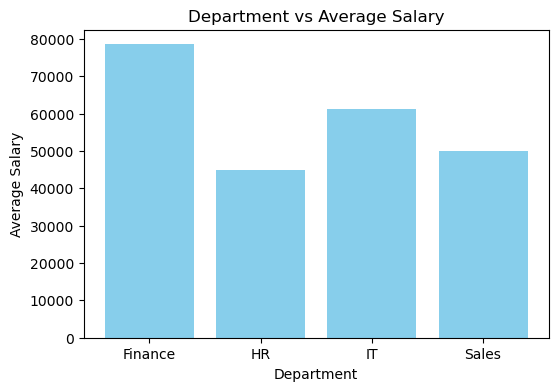

In [19]:
plt.figure(figsize=(6,4))
plt.bar(avg_salary.index,avg_salary.values,color="skyblue")
plt.title("Department vs Average Salary")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

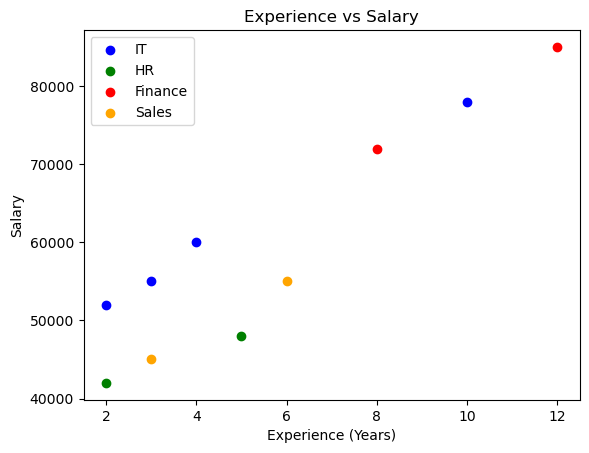

In [24]:
colors = {
    "IT":"blue",
    "HR":"green",
    "Finance":"red",
    "Sales":"orange"
}
for dept in df["department"].unique():
    d = df[df["department"] == dept]
    plt.scatter(d["experience_yrs"], d["salary"],color=colors[dept],label=dept)
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.legend()
plt.show()

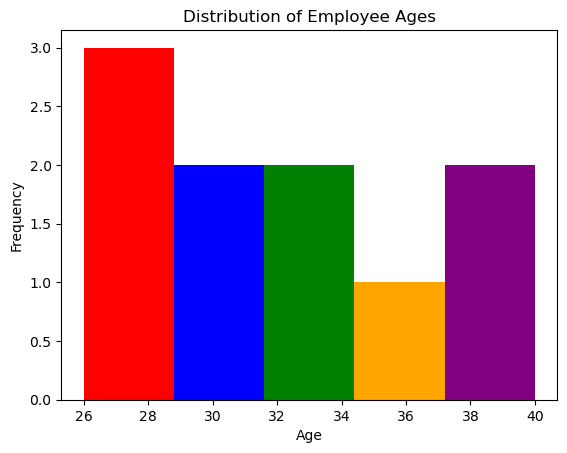

In [26]:
n,bins,patches=plt.hist(df["age"],bins=5)
colors = ["red","blue","green","orange","purple"]
for patch,color in zip(patches,colors):
    patch.set_facecolor(color)
plt.title("Distribution of Employee Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()